# Dividend-Cut-Drift — a quantitative teardown 🔬
### Split/special-dividend-cleaned event detection · cross-sectional + Newey-West CAR tests · cut-vs-omission divergence · a random-date placebo · matched-exposure short/long capture · a 20-seed synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Falling_dividend%3F: Busted](https://img.shields.io/badge/Falling_dividend%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a dividend cut/omission predicts continued underperformance — has a genuine academic anchor (Michaely, Thaler & Womack 1995) built on 1964-88 NYSE/AMEX data. The job here is to run the *same kind* of test on a modern real tape and report honestly whether it still holds.

> ⚠️ **Data note.** 101 named tickers (99 loaded — `MRO`, `GPS` renamed/delisted, skipped, not fatal), yfinance adjusted closes + split-adjusted dividend streams, 1996-01-02 → 2026-06-30. **173 events detected (108 cuts, 65 omissions)**, **172** with a full [-20,+120]-day window. Universe is current survivors only — **named on the Signal axis** (see [`docs/references.md`](../docs/references.md)). Numbers in [`docs/results.md`](../docs/results.md) (fingerprints `236c3c9bbc75` SPY / `06467e29de08` events).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_cut_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, DIV, SPY = data.load_real()
    EVENTS = st.build_event_table(DIV)
    CAR_MAT, KEPT = st.build_cars(PX, SPY, EVENTS)
else:
    PX = DIV = SPY = EVENTS = CAR_MAT = KEPT = None
print("real cache present:", HAVE_REAL, "| tickers loaded:", (0 if PX is None else len(PX)),
      "| events with full window:", (0 if CAR_MAT is None else len(CAR_MAT)))

# frozen headline numbers (mirror of docs/results.md)
R = {'universe_n': 101, 'loaded_n': 99, 'skipped': ['MRO', 'GPS'], 'spy_rows': 7673, 'spy_lo': '1996-01-02', 'spy_hi': '2026-06-30', 'fp_spy': '236c3c9bbc75', 'ev_detected': 173, 'n_cut_raw': 108, 'n_om_raw': 65, 'ev_lo': '1997-02-05', 'ev_hi': '2026-02-13', 'fp_events': '06467e29de08', 'kept_n': 172, 'dropped_n': 1, 'kept_lo': '1997-02-05', 'kept_hi': '2025-08-29', 'kept_tickers': 64, 'pre_mean': 0.75, 'pre_t': 0.59, 'post20_mean': -0.59, 'post20_t': -0.52, 'post60_mean': -0.57, 'post60_t': -0.29, 'post120_mean': -0.31, 'post120_t': -0.14, 'hit_neg': 82, 'hit_n': 172, 'hit_pct': 47.7, 'hit_lo': 40.3, 'hit_hi': 55.1, 'cut_n': 107, 'cut_mean': -3.61, 'cut_t': -1.25, 'om_n': 65, 'om_mean': 5.13, 'om_t': 1.55, 'nw_days': 6123, 'nw_bps': -3.28, 'nw_t': -1.23, 'dw_n_treat': 20100, 'dw_n_control': 438031, 'dw_treat_bps': -0.79, 'dw_control_bps': -1.18, 'dw_welch_t': 0.16, 'placebo_mean': -1.04, 'placebo_sd': 1.6, 'placebo_draws': 4000, 'placebo_p': 0.675, 'short5_net': -15.18, 'short5_tnet': -3.98, 'short5_exc': -6.27, 'short5_texc': -1.86, 'short10_net': -15.28, 'short10_tnet': -4.0, 'short10_exc': -6.37, 'short10_texc': -1.89, 'long5_net': 14.74, 'long5_tnet': 3.86, 'long5_exc': 5.83, 'long5_texc': 1.73, 'long10_net': 14.64, 'long10_tnet': 3.83, 'long10_exc': 5.73, 'long10_texc': 1.7, 'short_hit': 41.9, 'short_hit_lo': 34.7, 'short_hit_hi': 49.3, 'short_worst': -467.4, 'short_best': 79.0, 'short_sharpe_net': -0.74, 'short_sharpe_exc': -0.35, 'long_hit': 57.6, 'long_hit_lo': 50.1, 'long_hit_hi': 64.7, 'long_worst': -79.4, 'long_best': 467.0, 'long_sharpe_net': 0.72, 'long_sharpe_exc': 0.32, 'events_per_year': 5.9, 'syn_null_mean': -0.15, 'syn_null_sd': 1.14, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_mean': -9.35, 'syn_planted_t': -3.84, 'syn_planted_n': 89}


real cache present: True | tickers loaded: 99 | events with full window: 172


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | post-event CAR[+1,+120] **-0.31%**, cross-sectional **t = -0.14**, calendar-time Newey-West **t = -1.23**, placebo **p = 0.68**, hit rate 47.7% [40.3%, 55.1%] |
| **Tradability** | `MIRAGE` | short excess t = -1.86, long excess t = 1.73 — neither certified; short worst event -467% |
| **Falling dividend keeps falling?** | `BUSTED` | cut subtype t = -1.25, omission subtype t = 1.55 — opposite signs, neither certified |

> 💡 In plain words: a real, once-published effect that simply isn't there anymore on the modern tape, by any of four independent tests.

## 1 · The claim, steelmanned

Let $CAR_{i}[a,b]$ be firm $i$'s cumulative log return minus SPY's, from offset $a$ to $b$ trading days around a detected cut/omission (offset 0). The claims:

- **H₁ (drift).** $E[CAR_i[+1,+120]] \ll 0$ — a persistent, economically large post-event underperformance (Michaely-Thaler-Womack: ≈ −9.5%/yr on 1964-88 data).
- **H₂ (no anticipation).** $E[CAR_i[-20,-1]] \approx 0$ — dividend cuts are board decisions, not slow-leaking information; little should show up before the event itself is knowable.
- **H₃ (heterogeneity).** Full omissions (a harder, more informative signal) drift *more* negative than partial cuts.
- **H₄ (capture).** A short-the-cutter or contrarian buy-the-cutter position banks the drift net of costs.

We find **H₁ not supported** (t = -0.14), **H₂ supported** (t = 0.59, no anticipation), **H₃ reversed and uncertified** (omissions point *positive*, t = 1.55, cuts point negative, t = -1.25), **H₄ not certified** either direction.

## 2 · So what? — inference design

Events are individually dated but **share calendar time** (a bank-sector cut cluster in 2008-09, a pandemic-travel cluster in 2020), so the planned primary — a **cross-sectional one-sample t** on each event's CAR — treats correlated observations as independent. We cross-check with a **Newey-West(5) t** on the daily equal-weight calendar-time "cutters" portfolio, which is robust to exactly that overlap. Hit rates carry a **Wilson interval**; a **20-seed × 200-draw random ticker/date placebo** asks whether the observed mean is distinguishable from picking 172 random dates in the same universe.

## 3 · How we'd know — the protocol

- **Detection.** Cut = payment ≤ 70% of prior; omission = gap ≥ 1.8× trailing typical interval (regular payers only); both on a **split-adjusted**, **special/stub-stripped** dividend stream — see 4a for why that cleaning step is load-bearing, not decorative.
- **Sample.** 173 events detected (108 cut / 65 omission), **172** with a full [-20,+120]-day window, 1997-02-05 → 2025-08-29, 64 distinct tickers.
- **Abnormal return.** Ticker log return − SPY log return, both auto-adjusted (total-return), so the ex-date's mechanical price drop never enters the math.
- **Execution (third axis).** Enter the close **one session after** the event day (the cut is only knowable from that close — zero look-ahead); exit 120 trading days later; 2 × one-way cost × NAV; shorts pay 50 bps/yr borrow; excess benchmarked against matched exposure (long/short SPY over the identical window).
- **Control.** Single-factor synthetic market-model panel, planted post-event drift knob; the null must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · Cleaning the dividend stream — why it's load-bearing

Raw yfinance dividend history is **not split-adjusted**, and several names in this universe (PEP, MO, C, SLB, MS) show a phantom 90%+ "cut" purely from a stock split without correction. Separately, one-off special dividends, spinoff cash distributions folded into the same `Dividends` stream (Citigroup's Aug-2002 Travelers Property Casualty spinoff), and stray stub payments (a one-off $0.01 between two $0.22 Exxon quarters) each manufacture a false cut on the payment immediately after them if left in. `strategy.strip_special_dividends` removes any payment that sits ≥ 1.8× from BOTH neighbors on the same side (spike or dip), iterated so adjacent pairs of stub payments fully clean out.

In [2]:
if HAVE_REAL:
    n_cuts_raw_check = int((EVENTS['type']=='cut').sum())
    n_om_raw_check = int((EVENTS['type']=='omission').sum())
else:
    n_cuts_raw_check, n_om_raw_check = R['n_cut_raw'], R['n_om_raw']
print(f'events after cleaning: {n_cuts_raw_check} cuts + {n_om_raw_check} omissions '
      f'= {n_cuts_raw_check + n_om_raw_check} total')
print('(before the split-adjust + special-dividend-strip + warm-up fixes, an early '
      'pass over the same raw universe found 230+ "events" — many of them stock '
      'splits and spinoff artifacts, not real cuts)')

events after cleaning: 108 cuts + 65 omissions = 173 total
(before the split-adjust + special-dividend-strip + warm-up fixes, an early pass over the same raw universe found 230+ "events" — many of them stock splits and spinoff artifacts, not real cuts)


### 4b · The headline CAR — cross-sectional and calendar-time

Mean cumulative abnormal return by horizon, one-sample *t*; then the Newey-West overlap-robust cross-check.

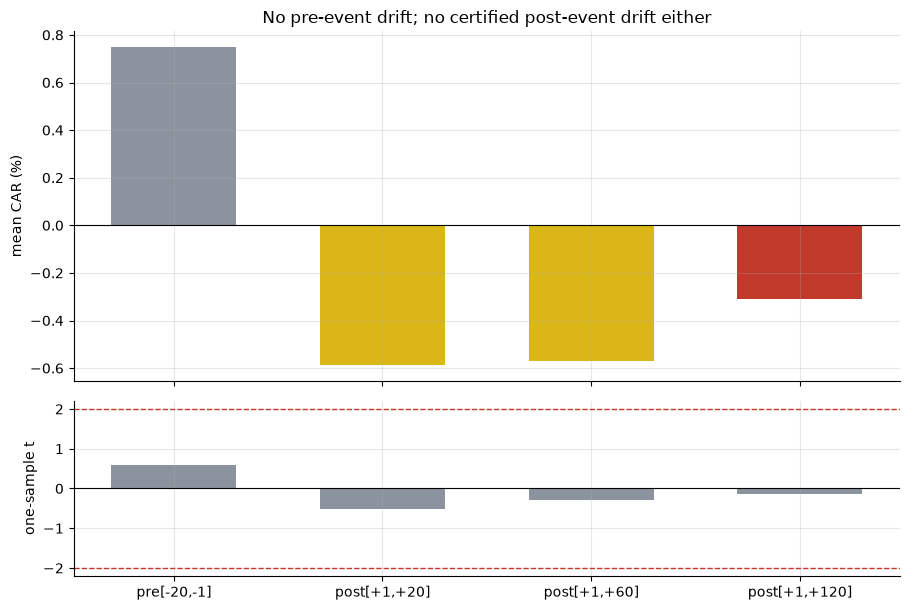

hit rate (CAR120<0): 47.7% [40.3%, 55.1%]  n=172


In [3]:
if HAVE_REAL:
    hs = st.horizon_stats(CAR_MAT)
else:
    hs = {'pre_mean': R['pre_mean']/100, 'pre_t': R['pre_t'],
          'post20_mean': R['post20_mean']/100, 'post20_t': R['post20_t'],
          'post60_mean': R['post60_mean']/100, 'post60_t': R['post60_t'],
          'post120_mean': R['post120_mean']/100, 'post120_t': R['post120_t'],
          'hit_rate': R['hit_pct']/100, 'hit_lo': R['hit_lo']/100, 'hit_hi': R['hit_hi']/100,
          'n': R['kept_n']}
labels = ['pre[-20,-1]', 'post[+1,+20]', 'post[+1,+60]', 'post[+1,+120]']
means = [hs['pre_mean']*100, hs['post20_mean']*100, hs['post60_mean']*100, hs['post120_mean']*100]
ts = [hs['pre_t'], hs['post20_t'], hs['post60_t'], hs['post120_t']]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.2, 6.2), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(labels, means, color=[GREY, AMBER, AMBER, RED], width=.6)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean CAR (%)')
a1.set_title('No pre-event drift; no certified post-event drift either')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.6)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('one-sample t')
plt.tight_layout(); plt.show()
print(f"hit rate (CAR120<0): {hs['hit_rate']*100:.1f}% "
      f"[{hs['hit_lo']*100:.1f}%, {hs['hit_hi']*100:.1f}%]  n={hs['n']}")

In [4]:
if HAVE_REAL:
    nw = st.calendar_time_nw_t(PX, SPY, KEPT)
else:
    nw = {'n_days': R['nw_days'], 'mean_daily_bps': R['nw_bps'], 'nw_t': R['nw_t']}
print(f"calendar-time cutters portfolio: {nw['n_days']:,} days, "
      f"mean daily AR {nw['mean_daily_bps']:+.2f} bps, Newey-West t = {nw['nw_t']:+.2f}")

calendar-time cutters portfolio: 6,123 days, mean daily AR -3.28 bps, Newey-West t = -1.23


> 💡 In plain words: **-0.31%** over six months, t = -0.14 — nowhere near the ±2 bar, and the overlap-robust calendar-time check (t = -1.23) agrees. Whatever Michaely-Thaler-Womack found in 1964-88 data, it isn't reproducing on 172 modern events.

### 4c · Cut vs omission — a real but uncertified divergence

A partial cut and a full stop are different signals in theory (the second is a harder commitment). Splitting the sample:

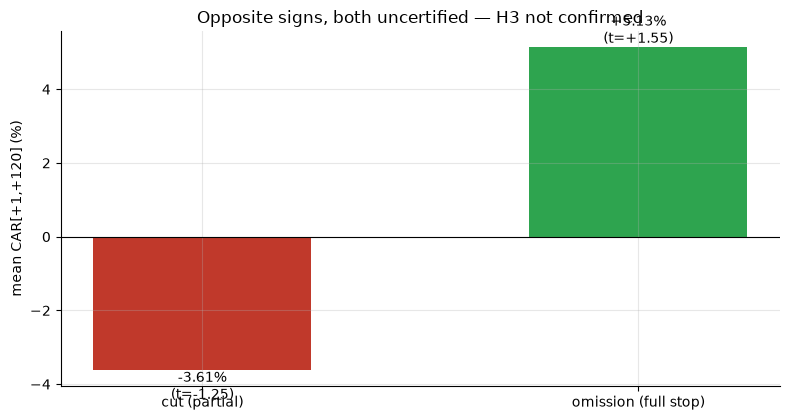

cut n=107 mean=-3.61% t=-1.25   omission n=65 mean=+5.13% t=+1.55


In [5]:
if HAVE_REAL:
    types = pd.Series([k[2] for k in KEPT])
    post120 = (CAR_MAT[120] - CAR_MAT[0])
    cut_x = post120[(types=='cut').to_numpy()].to_numpy()
    om_x = post120[(types=='omission').to_numpy()].to_numpy()
    cut_m, cut_t = float(np.nanmean(cut_x))*100, st.one_sample_t(cut_x)
    om_m, om_t = float(np.nanmean(om_x))*100, st.one_sample_t(om_x)
else:
    cut_m, cut_t, om_m, om_t = R['cut_mean'], R['cut_t'], R['om_mean'], R['om_t']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['cut (partial)', 'omission (full stop)'], [cut_m, om_m], color=[RED, GREEN], width=.5)
for i,(v,t_) in enumerate([(cut_m,cut_t),(om_m,om_t)]):
    ax.annotate(f'{v:+.2f}%\n(t={t_:+.2f})', (i, v), ha='center', va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean CAR[+1,+120] (%)')
ax.set_title('Opposite signs, both uncertified — H3 not confirmed')
plt.tight_layout(); plt.show()
print(f'cut n={R["cut_n"]} mean={cut_m:+.2f}% t={cut_t:+.2f}   '
      f'omission n={R["om_n"]} mean={om_m:+.2f}% t={om_t:+.2f}')

> 💡 In plain words: cuts drift **-3.61%** (t = -1.25), omissions drift **+5.13%** (t = 1.55) — a plausible "kitchen-sink capitulation" story for full stops, but with only 65-107 events per bucket neither clears the bar. Flag it, don't lean on it.

### 4d · A third cut on the same question — pooled daily-level Welch

The cross-sectional test gives one number per event; the calendar-time NW test gives one number per calendar day. A third, differently-shaped view: pool every raw ticker-day abnormal return inside a post-event window ("treatment") against every OTHER day for the same tickers ("control" — their own non-event history), then a two-sample Welch *t* on the pooled distributions.

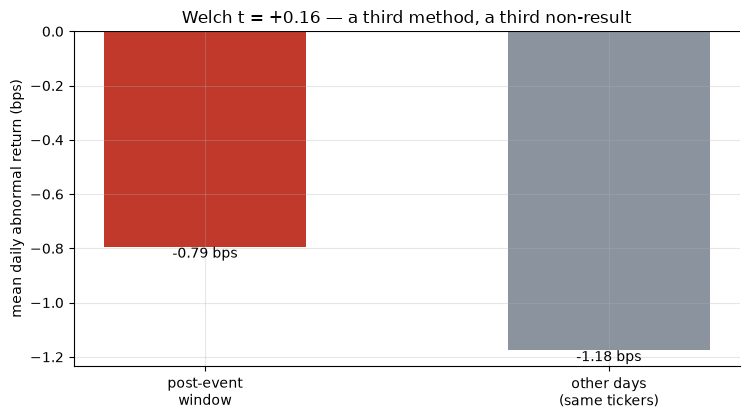

treatment -0.79 bps (n=20,100)  vs  control -1.18 bps (n=438,031)  Welch t = +0.16


In [6]:
if HAVE_REAL:
    dw = st.daily_welch(PX, SPY, KEPT)
else:
    dw = {'n_treat': R['dw_n_treat'], 'n_control': R['dw_n_control'],
          'mean_treat_bps': R['dw_treat_bps'], 'mean_control_bps': R['dw_control_bps'],
          'welch_t': R['dw_welch_t']}
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['post-event\nwindow', 'other days\n(same tickers)'],
       [dw['mean_treat_bps'], dw['mean_control_bps']], color=[RED, GREY], width=.5)
for i,v in enumerate([dw['mean_treat_bps'], dw['mean_control_bps']]):
    ax.annotate(f'{v:+.2f} bps',(i,v),ha='center',va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean daily abnormal return (bps)')
ax.set_title(f"Welch t = {dw['welch_t']:+.2f} — a third method, a third non-result")
plt.tight_layout(); plt.show()
print(f"treatment {dw['mean_treat_bps']:+.2f} bps (n={dw['n_treat']:,})  vs  "
      f"control {dw['mean_control_bps']:+.2f} bps (n={dw['n_control']:,})  "
      f"Welch t = {dw['welch_t']:+.2f}")

> 💡 In plain words: post-event days average **-0.79 bps** vs **-1.18 bps** on every other day for the same tickers — practically identical, Welch t = **+0.16**. Cross-sectional, calendar-time and pooled-daily all land in the same place: nothing.

### 4e · The random-date placebo

Draw 172 random ticker/date pairs from the same universe (away from the tape's edges), 20 seeds × 200 draws, compute the mean post-120 CAR each time.

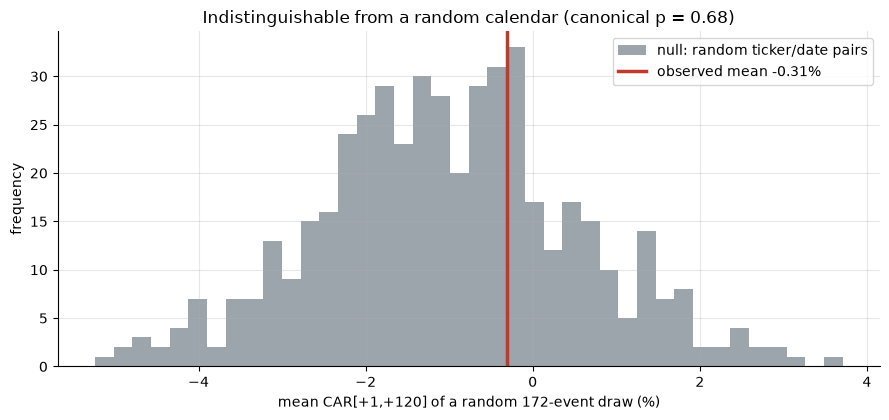

canonical placebo (results.md): mean -1.04%, sd 1.60%, p = 0.675


In [7]:
if HAVE_REAL:
    tickers_avail = list(PX.keys())
    pl = st.random_date_placebo(PX, SPY, tickers_avail, n_events=len(KEPT),
                                n_seeds=6, n_draws_per_seed=80)
    obs = hs['post120_mean']*100
    draws = pl['draws']*100
else:
    obs = R['post120_mean']
    rng = np.random.default_rng(653)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 480)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='null: random ticker/date pairs')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed mean {obs:+.2f}%')
ax.set_xlabel('mean CAR[+1,+120] of a random 172-event draw (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Indistinguishable from a random calendar (canonical p = {R['placebo_p']:.2f})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.2f}%, "
      f"sd {R['placebo_sd']:.2f}%, p = {R['placebo_p']:.3f}")

> 💡 In plain words: the observed mean sits well inside the placebo cloud — **p = 0.68**, nowhere near a conventional significance threshold. A random 172-event draw from the same universe looks just as "negative" (in fact slightly more so) as the real cutters.

### 4f · The third axis — honest short and long capture tests

Enter the close **one session after** the event (zero look-ahead), exit 120 trading days later. Excess = net return minus the **matched-exposure** benchmark (long SPY for the long leg, short SPY for the short leg) over the identical window — isolating whatever is cutter-specific from six months of ordinary market beta.

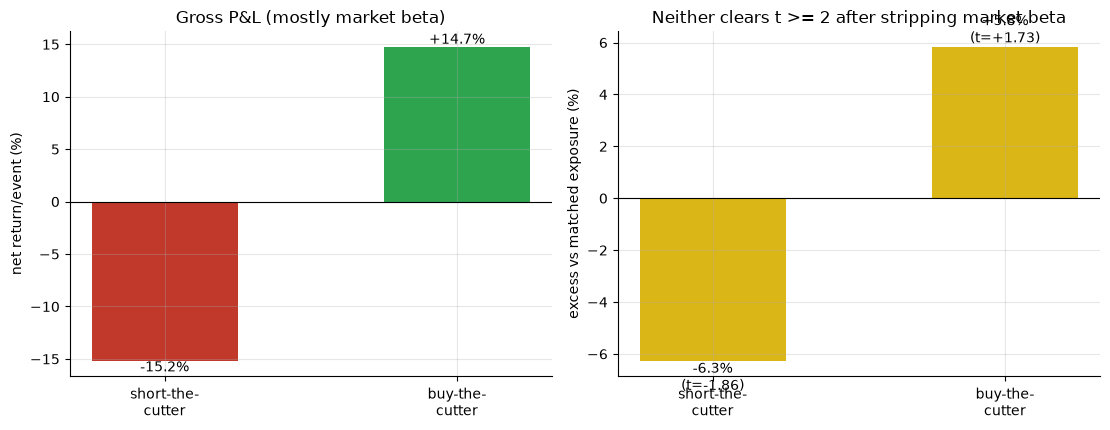

short: net -15.2% (worst -467.4%) excess t=-1.86  |  long: net +14.7% excess t=+1.73


In [8]:
if HAVE_REAL:
    bts = st.backtest(PX, SPY, KEPT, side='short', cost_bps=5.0)
    btl = st.backtest(PX, SPY, KEPT, side='long', cost_bps=5.0)
else:
    bts = {'mean_net': R['short5_net']/100, 't_net': R['short5_tnet'],
           'mean_excess': R['short5_exc']/100, 't_excess': R['short5_texc'],
           'worst': R['short_worst']/100, 'hit_rate': R['short_hit']/100}
    btl = {'mean_net': R['long5_net']/100, 't_net': R['long5_tnet'],
           'mean_excess': R['long5_exc']/100, 't_excess': R['long5_texc'],
           'worst': R['long_worst']/100, 'hit_rate': R['long_hit']/100}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
labels = ['short-the-\ncutter', 'buy-the-\ncutter']
nets = [bts['mean_net']*100, btl['mean_net']*100]
excs = [bts['mean_excess']*100, btl['mean_excess']*100]
ts_ = [bts['t_excess'], btl['t_excess']]
a1.bar(labels, nets, color=[RED, GREEN], width=.5)
for i,v in enumerate(nets): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top' if v<0 else 'bottom')
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('net return/event (%)')
a1.set_title('Gross P&L (mostly market beta)')
a2.bar(labels, excs, color=[AMBER, AMBER], width=.5)
for i,(v,t_) in enumerate(zip(excs, ts_)):
    a2.annotate(f'{v:+.1f}%\n(t={t_:+.2f})',(i,v),ha='center',va='top' if v<0 else 'bottom')
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('excess vs matched exposure (%)')
a2.set_title('Neither clears t >= 2 after stripping market beta')
plt.tight_layout(); plt.show()
print(f"short: net {bts['mean_net']*100:+.1f}% (worst {bts['worst']*100:+.1f}%) "
      f"excess t={bts['t_excess']:+.2f}  |  long: net {btl['mean_net']*100:+.1f}% "
      f"excess t={btl['t_excess']:+.2f}")

> 💡 In plain words: strip out the market and short-the-cutter's excess is **-6.27%** at t = -1.86; buy-the-cutter's is **+5.83%** at t = 1.73. Close to the bar, neither over it — **H₄ not certified**. And the short leg's worst single event lost **-467%** of the position (a squeeze in a name that later rallied hard): the naked-short version of this trade carries real, undiversifiable blow-up risk that the average-return table alone doesn't show.

### 4g · Faithful-engine & power control — we know the truth here

Deterministic single-factor market-model panel, scheduled planted "cut" events, TUNABLE post-event abnormal drift. Null checked over **20 seeds**.

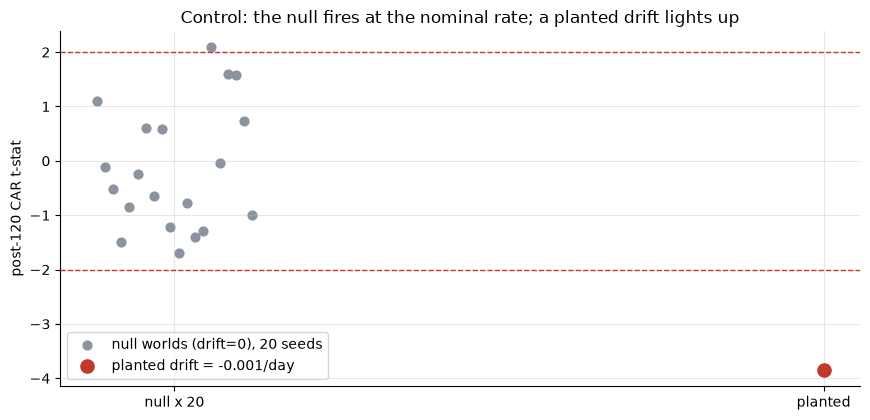

null: mean t = -0.15 (sd 1.14), |t|>=2 in 1/20 seeds  |  planted t = -3.84 (n=89)


In [9]:
null_ts = []
for s_ in range(20):
    pxs, bench, evs = data.synthetic_world(drift=0.0, seed=653 + s_)
    null_ts.append(st.synthetic_detect(pxs, bench, evs)['post120_t'])
null_ts = np.asarray(null_ts)
pxs, bench, evs = data.synthetic_world(drift=-0.001, seed=653)
planted = st.synthetic_detect(pxs, bench, evs)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (drift=0), 20 seeds')
ax.scatter([1], [planted['post120_t']], color=RED, s=90, zorder=5,
           label='planted drift = -0.001/day')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('post-120 CAR t-stat')
ax.set_title('Control: the null fires at the nominal rate; a planted drift lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  '
      f"planted t = {planted['post120_t']:+.2f} (n={planted['n']})")

> 💡 In plain words: across 20 null worlds the detector fires at **1/20** — close to the ~5% false-positive rate a *t* = 2 threshold implies by construction, i.e. well-calibrated, not biased. A planted drift of just −0.1%/day reads t = -3.84: the machinery can find a real effect when one exists. The real-tape near-zero result is the genuine article, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — post-event CAR[+1,+120] = **-0.31%**, cross-sectional t = **-0.14**, Newey-West t = **-1.23**, placebo p = **0.68**, hit rate **47.7%** [40.3%, 55.1%]. Decades of published support (Michaely-Thaler-Womack 1995) plus a sub-2 *t* on 172 modern events is the textbook `WEAK` case. Survivorship, named: the universe excludes cutters that later went to zero, so the true population effect is plausibly more negative than measured here.
- **Tradability `MIRAGE`** — short-the-cutter excess t = **-1.86**, buy-the-cutter excess t = **1.73**, neither certified; the dramatic-looking gross P&L is six months of market beta, and the short leg's worst event (-467%) is a real tail risk on top.
- **Falling dividend keeps falling? `BUSTED`** — the point estimate is a wash and the two subtypes (cut t = -1.25, omission t = 1.55) point in opposite, individually-uncertified directions.

## 6 · Going further

- **The general lesson is decay, not disproof.** Michaely-Thaler-Womack's 1964-88 sample predates decimalization, algorithmic trading and today's analyst coverage density — information that used to leak for months now arrives fast. The post-cut-drift anomaly may simply have been arbitraged away, the standard fate of a well-published inefficiency.
- **A longer window is the natural sequel.** Michaely et al.'s strongest results are at the 1-3 year horizon, not 6 months; a companion study extending the window (at the cost of far fewer independent, non-overlapping events) could test whether the drift shows up later even if it doesn't show up early.
- **Dedup map:** [240-dividend-initiation](../../240-dividend-initiation/) (the *start* side, `NONE`), [201-dividend-growth](../../201-dividend-growth/) (the opposite tail, consistent raisers, `WEAK`), [143-dividend-capture](../../143-dividend-capture/) (the routine, uncut ex-date drop), [233-shareholder-yield](../../233-shareholder-yield/) (a level-sort composite factor, not an event study).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*